# Diffusion Cascade Exploration

Interactive exploration of IC, SI, and SIR diffusion models on ER, BA, and Complete networks.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import networkx as nx
from networks.generator import compute_network_stats
from diffusion.models import r0_to_params, create_model, CascadeResult
from diffusion.simulator import select_sources, run_experiment, compute_cascade_stats
from diffusion.cascade_viz import plot_cascade_tree, plot_comparison_grid

# Load networks
networks = {
    'ER': nx.convert_node_labels_to_integers(nx.read_graphml('../data/networks/er_network.graphml')),
    'BA': nx.convert_node_labels_to_integers(nx.read_graphml('../data/networks/ba_network.graphml')),
    'Complete': nx.convert_node_labels_to_integers(nx.read_graphml('../data/networks/complete_network.graphml')),
}
stats = {k: compute_network_stats(v) for k, v in networks.items()}
print('Networks loaded ✓')

Networks loaded ✓


In [2]:
# Run a single IC cascade on the BA network
G = networks['BA']
avg_deg = stats['BA']['avg_degree']
r0 = 2.0

params = r0_to_params(r0, avg_deg, 'IC')
model = create_model('IC', **params)
result = model.run(G, source=42, seed=123)
result.network_name = 'BA'

s = compute_cascade_stats(result, G)
print(f"Cascade size: {s['size']}, Depth: {s['depth']}, Actual R₀: {s['actual_r0']}, Coverage: {s['coverage_pct']}%")

c:\Users\andre\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Cascade size: 80, Depth: 8, Actual R₀: 2.633, Coverage: 80.0%


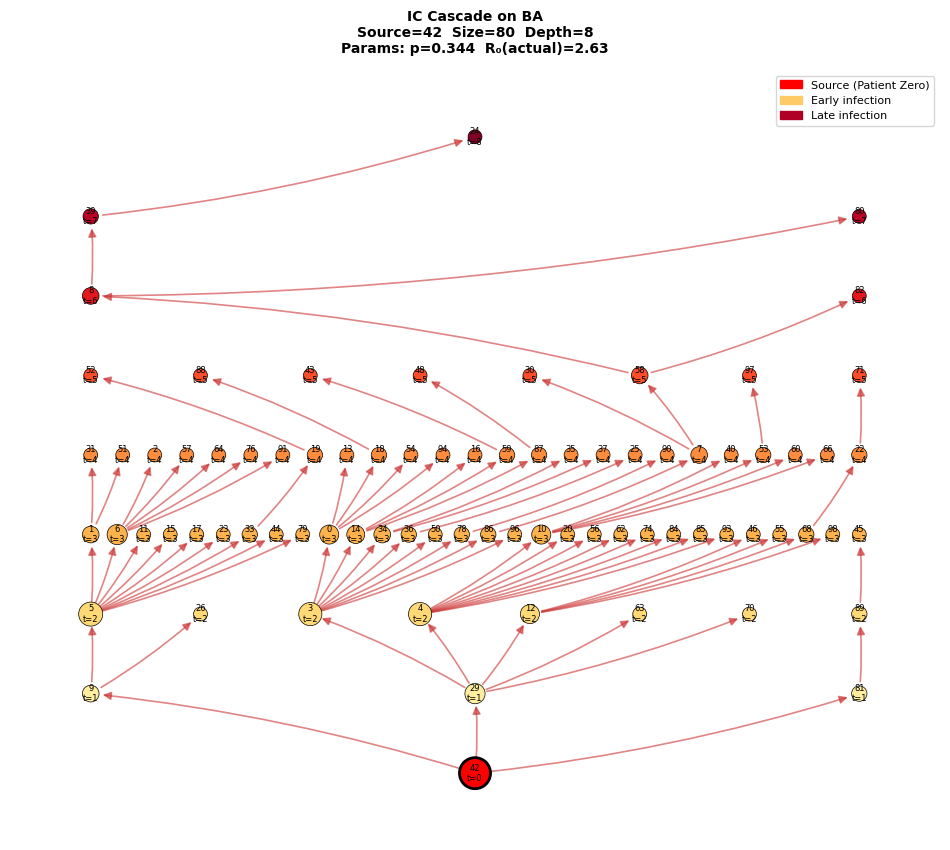

In [7]:
%matplotlib inline
plot_cascade_tree(result, G, figsize=(12, 10));

ER: size=87, R₀=1.83
BA: size=80, R₀=2.63
Complete: size=83, R₀=1.64


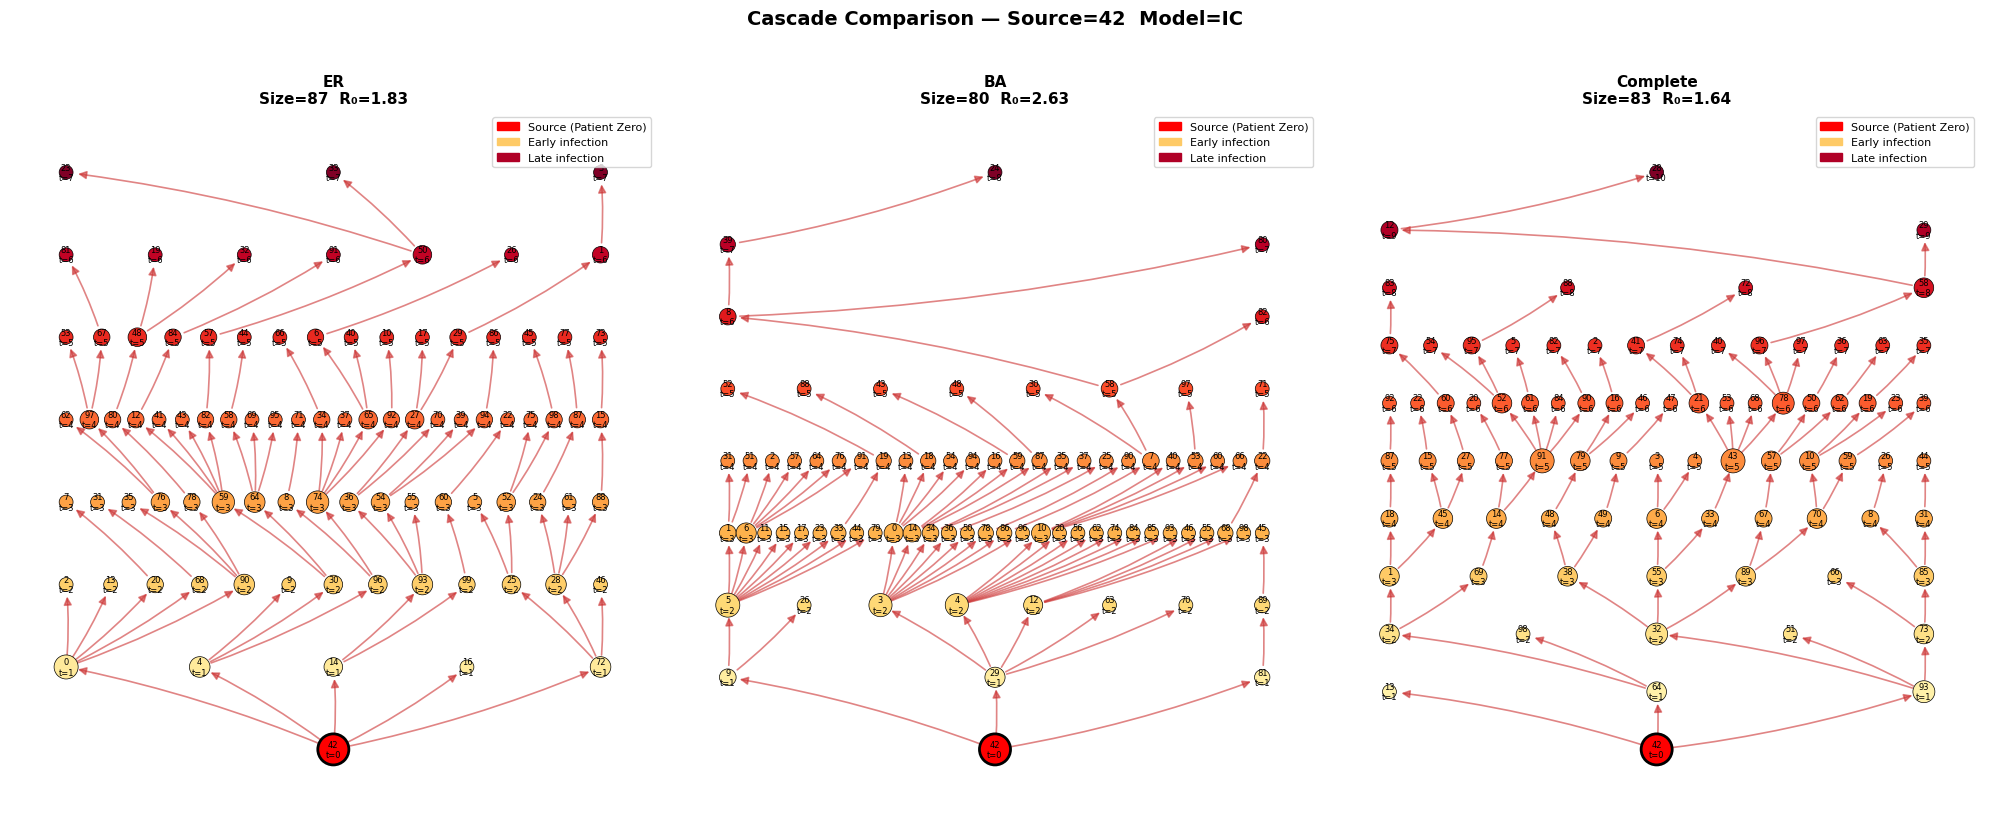

In [8]:
# Compare same model across all three networks
comparison = {}
for name, G in networks.items():
    avg_deg = stats[name]['avg_degree']
    params = r0_to_params(2.0, avg_deg, 'IC')
    model = create_model('IC', **params)
    res = model.run(G, source=42, seed=123)
    res.network_name = name
    comparison[name] = res
    print(f"{name}: size={res.size}, R₀={res.actual_r0():.2f}")

plot_comparison_grid(comparison, figsize=(20, 8));  # Added semicolon